# 05 — Poređenje metoda i zaključci


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

import ast

## Učitavanje sačuvanih rezultata

In [19]:
kolone = ['dataset', 'model', 'method', 'mean_score', 'std_score',
          'n_evaluations', 'mean_time_sec', 'best_params']
rezultati = pd.read_csv('./results/all_results.csv', names=kolone)
rezultati

,dataset,model,method,mean_score,std_score,n_evaluations,mean_time_sec,best_params
0,breast_cancer,svm,grid_search,0.944606,0.004981,25,0.310282,"{'C': 1, 'gamma': 0.0001}"
1,breast_cancer,random_forest,grid_search,0.961971,0.002412,60,14.186125,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
2,digits,svm,grid_search,0.990814,0.002106,25,1.819838,"{'C': 1, 'gamma': 0.001}"
3,digits,random_forest,grid_search,0.975017,0.001570,60,18.726578,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
4,breast_cancer,svm,random_search,0.939116,0.005188,25,0.234502,"{'C': 0.5545996722241042, 'gamma': 0.000126971..."
5,breast_cancer,random_forest,random_search,0.962851,0.002863,60,11.869927,"{'max_depth': 17, 'min_samples_split': 2, 'n_e..."
6,digits,svm,random_search,0.989214,0.002047,25,1.675994,"{'C': 24.335817588808077, 'gamma': 0.000208248..."
7,digits,random_forest,random_search,0.974530,0.001710,60,17.155604,"{'max_depth': 16, 'min_samples_split': 2, 'n_e..."
8,breast_cancer,svm,nelder_mead,0.817567,0.153472,28,0.914525,"{'C': 0.9945462861933386, 'gamma': 0.000112201..."
9,breast_cancer,random_forest,nelder_mead,0.959113,0.004414,50,12.213801,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."


## Tabelarni pregled

In [20]:
pivot_score = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='mean_score')
pivot_score

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest     0.961971     0.959113       0.962851
              svm               0.944606     0.817567       0.939116
digits        random_forest     0.975017     0.973556       0.974530
              svm               0.990814     0.990884       0.989214

In [21]:
pivot_std = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='std_score')
pivot_std

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest     0.002412     0.004414       0.002863
              svm               0.004981     0.153472       0.005188
digits        random_forest     0.001570     0.001968       0.001710
              svm               0.002106     0.001827       0.002047

In [22]:
pivot_vreme = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='mean_time_sec')
pivot_vreme

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest    14.186125    12.213801      11.869927
              svm               0.310282     0.914525       0.234502
digits        random_forest    18.726578    22.941052      17.155604
              svm               1.819838     2.555218       1.675994

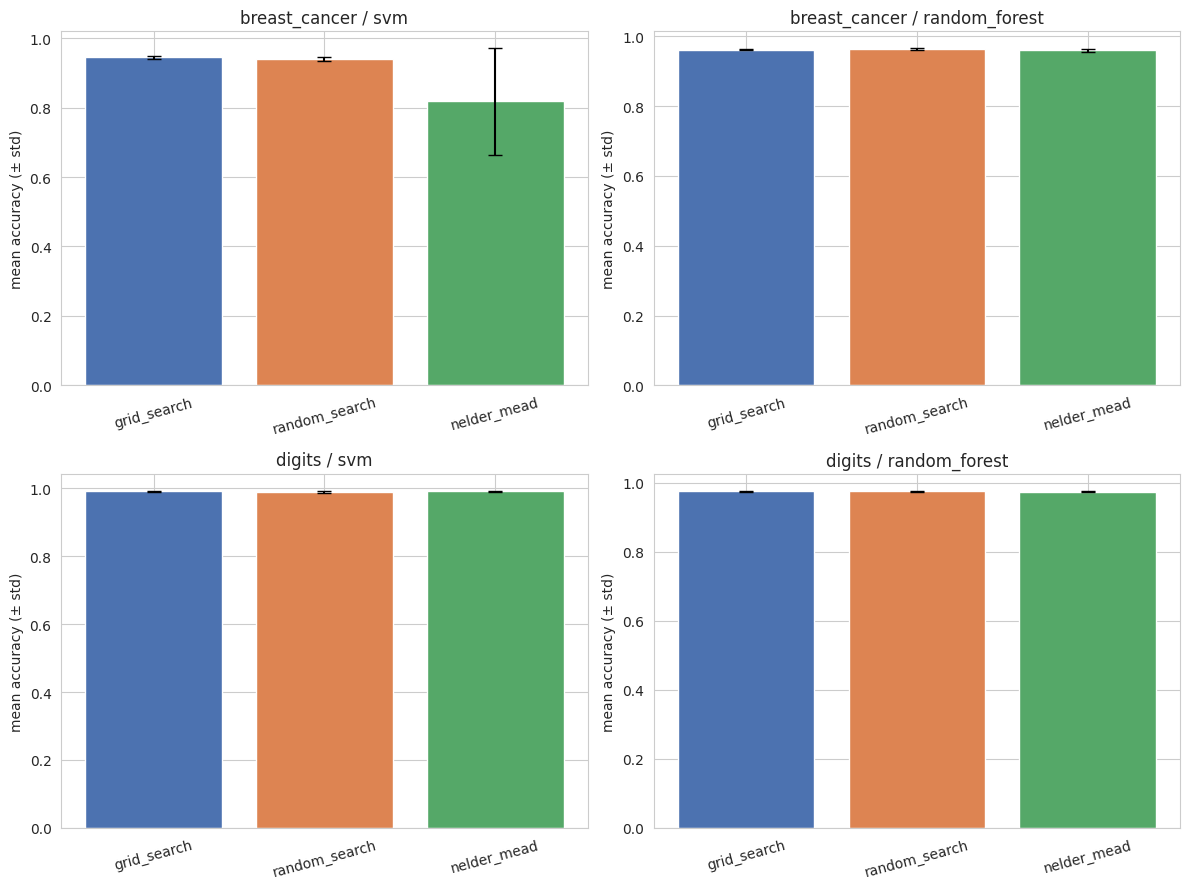

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
kombinacije = rezultati[['dataset', 'model']].drop_duplicates().values

for ax, (ime_skupa, ime_modela) in zip(axes.flat, kombinacije):
    podskup = rezultati[(rezultati['dataset'] == ime_skupa) & (rezultati['model'] == ime_modela)]
    ax.bar(podskup['method'], podskup['mean_score'], yerr=podskup['std_score'],
           capsize=5, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{ime_skupa} / {ime_modela}')
    ax.set_ylabel('mean accuracy (± std)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

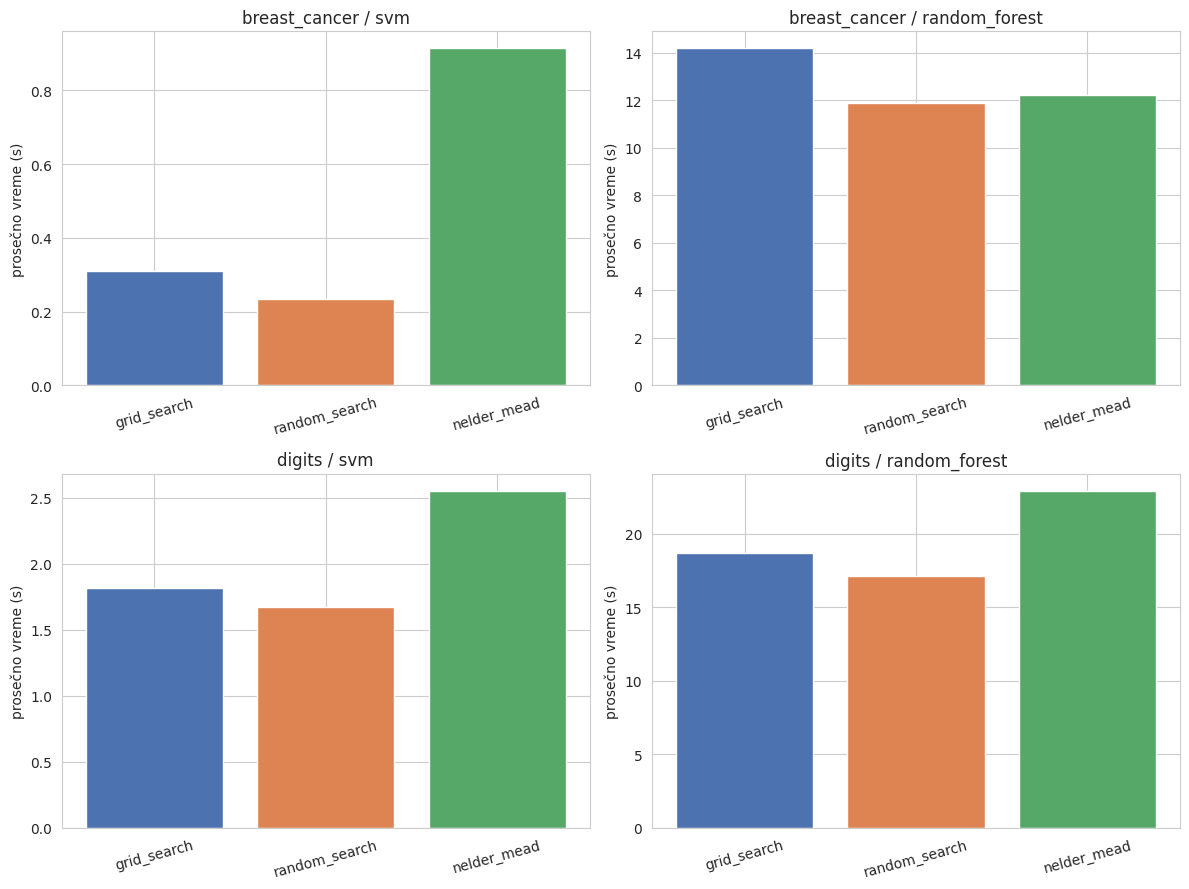

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (ime_skupa, ime_modela) in zip(axes.flat, kombinacije):
    podskup = rezultati[(rezultati['dataset'] == ime_skupa) & (rezultati['model'] == ime_modela)]
    ax.bar(podskup['method'], podskup['mean_time_sec'], color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{ime_skupa} / {ime_modela}')
    ax.set_ylabel('prosečno vreme (s)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Najbolja kombinacija

In [24]:
najbolji_red = rezultati.loc[rezultati['mean_score'].idxmax()]
print('Najbolja kombinacija (po prosečnom rezultatu preko 10 seed-ova):')
print(najbolji_red[['dataset', 'model', 'method', 'mean_score', 'std_score']])
print()
print('Reprezentativni hiperparametri (iz najboljeg pojedinačnog pokretanja):')
print(ast.literal_eval(najbolji_red['best_params']))

Najbolja kombinacija (po prosečnom rezultatu preko 10 seed-ova):
dataset            digits
model                 svm
method        nelder_mead
mean_score       0.990884
std_score        0.001827
Name: 10, dtype: object

Reprezentativni hiperparametri (iz najboljeg pojedinačnog pokretanja):
{'C': 0.9968389521625052, 'gamma': 0.0007943282347242919}


## Finalna provera na test skupu

Sve do sada prikazane vrednosti (`mean_score`, `std_score`) su procene dobijene preko unakrsne validacije na trening delu. Da bismo proverili da li te procene zaista odražavaju ponašanje na neviđenim podacima, sada za svaku kombinaciju uzimamo njene reprezentativne hiperparametre, treniramo model na celom trening delu, i evaluiramo ga na test delu, koji nijedna metoda nije videla tokom pretrage.

In [25]:
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [27]:
#ista podela kao u ostalim
breast_cancer = load_breast_cancer()
digits = load_digits()

X_bc, y_bc = breast_cancer.data, breast_cancer.target
X_dg, y_dg = digits.data, digits.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
X_dg_train, X_dg_test, y_dg_train, y_dg_test = train_test_split(
    X_dg, y_dg, test_size=0.2, random_state=42, stratify=y_dg)

trening_test_podaci = {
    'breast_cancer': (X_bc_train, y_bc_train, X_bc_test, y_bc_test),
    'digits': (X_dg_train, y_dg_train, X_dg_test, y_dg_test),
}

In [29]:
test_rezultati = []  

for _, red in rezultati.iterrows():
    ime_skupa = red['dataset']
    ime_modela = red['model']
    ime_metode = red['method']
    params = ast.literal_eval(red['best_params'])

    X_train, y_train, X_test, y_test = trening_test_podaci[ime_skupa]

    if ime_modela == 'svm':
        model = SVC(kernel='rbf', random_state=42, **params)
    else:
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)

    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    test_rezultati.append({
        'dataset': ime_skupa,
        'model': ime_modela,
        'method': ime_metode,
        'cv_mean_score': red['mean_score'],   
        'test_accuracy': test_acc,             
    })

df_test = pd.DataFrame(test_rezultati)
df_test['razlika'] = df_test['test_accuracy'] - df_test['cv_mean_score']
df_test

,dataset,model,method,cv_mean_score,test_accuracy,razlika
0,breast_cancer,svm,grid_search,0.944606,0.929825,-0.014782
1,breast_cancer,random_forest,grid_search,0.961971,0.956140,-0.005831
2,digits,svm,grid_search,0.990814,0.988889,-0.001925
3,digits,random_forest,grid_search,0.975017,0.969444,-0.005573
4,breast_cancer,svm,random_search,0.939116,0.929825,-0.009292
5,breast_cancer,random_forest,random_search,0.962851,0.956140,-0.006711
6,digits,svm,random_search,0.989214,0.994444,0.005231
7,digits,random_forest,random_search,0.974530,0.966667,-0.007864
8,breast_cancer,svm,nelder_mead,0.817567,0.929825,0.112257
9,breast_cancer,random_forest,nelder_mead,0.959113,0.956140,-0.002973


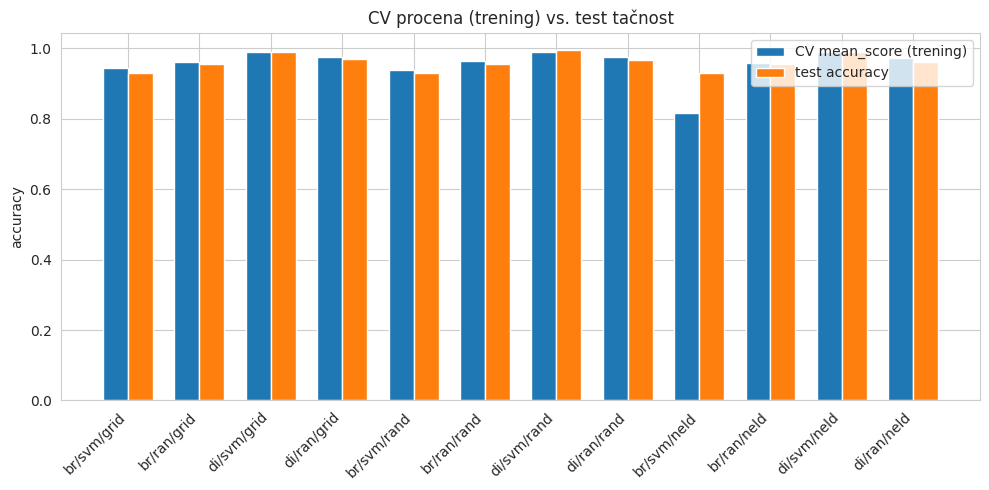

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pozicije = np.arange(len(df_test))
sirina = 0.35

ax.bar(x_pozicije - sirina/2, df_test['cv_mean_score'], sirina, label='CV mean_score (trening)')
ax.bar(x_pozicije + sirina/2, df_test['test_accuracy'], sirina, label='test accuracy')

oznake = df_test['dataset'].str[:2] + '/' + df_test['model'].str[:3] + '/' + df_test['method'].str[:4]
ax.set_xticks(x_pozicije)
ax.set_xticklabels(oznake, rotation=45, ha='right')
ax.set_ylabel('accuracy')
ax.set_title('CV procena (trening) vs. test tačnost')
ax.legend()
plt.tight_layout()
plt.show()

## Matrica konfuzije najbolje kombinacije 

In [32]:
najbolji_test_red = df_test.loc[df_test['test_accuracy'].idxmax()]
print('Najbolja kombinacija na test skupu:')
print(najbolji_test_red)

X_train, y_train, X_test, y_test = trening_test_podaci[najbolji_test_red['dataset']]
izvorni_red = rezultati[
    (rezultati['dataset'] == najbolji_test_red['dataset']) &
    (rezultati['model'] == najbolji_test_red['model']) &
    (rezultati['method'] == najbolji_test_red['method'])
].iloc[0]
params = ast.literal_eval(izvorni_red['best_params'])

if najbolji_test_red['model'] == 'svm':
    finalni_model = SVC(kernel='rbf', random_state=42, **params)
else:
    finalni_model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)

finalni_model.fit(X_train, y_train)

Najbolja kombinacija na test skupu:
dataset                 digits
model                      svm
method           random_search
cv_mean_score         0.989214
test_accuracy         0.994444
razlika               0.005231
Name: 6, dtype: object


SVC(C=24.335817588808077, gamma=0.0002082485125344959, random_state=42)

## Zaključci

**Koja metoda daje najbolji `mean_score`, po skupu podataka i po modelu?** Razlike između metoda su uglavnom sitne i statistički beznačajne. Grid Search je neznatno najbolji na `breast_cancer/svm` (0.9446) i `digits/random_forest` (0.9750); Random Search na `breast_cancer/random_forest` (0.9629); Nelder-Mead "pobeđuje" na `digits/svm` (0.9909), ali za svega 0.0001–0.002 u odnosu na ostale dve.

**Da li se `mean_score` (CV) i `test_accuracy` slažu?** Da, u 11 od 12 kombinacija — razlike su male i uglavnom blago negativne. Jedini izuzetak je `breast_cancer/svm/nelder_mead`, gde je `mean_score` bio 0.8176 a `test_accuracy` čak 0.9298. To nije overfitting, već posledica visoke varijanse same pretrage — reprezentativni hiperparametri su ispravni, ali prosek preko 10 pokretanja je bio zavaran zbog nekoliko neuspešnih pokušaja.

**Koja metoda ima najmanji `std_score` (najstabilnija)?** Grid i Random Search su podjednako i dosledno stabilni na svih 12 kombinacija (std između 0.0015 i 0.0052). Nelder-Mead je uporedivo stabilan na 3 od 4 kombinacije, ali nestabilan na `breast_cancer/svm` (std=0.1535, veći nego bilo gde drugde). Uzrok: atributi u Breast Cancer skupu nisu standardizovani.

**Koja metoda daje najbolji odnos kvalitet/vreme?** Random Search je dosledno najbrži ili skoro najbrži optimizator u sve 4 kombinacije, uz kvalitet identičan Grid Search-u — najbolji sveukupni kompromis. Nelder-Mead je, iznenađujuće, **najsporiji u svih 12 kombinacija** (npr. `digits/random_forest`: ~23s naspram ~17-19s kod GS/RS) uprkos sličnom ili manjem broju evaluacija. U kombinaciji sa nestabilnošću na SVM-u, ovo ga čini najlošijim izborom po odnosu kvalitet/cena/pouzdanost u ovom istraživanju.

**SVM naspram Random Forest-a.** Očekivanje da će Nelder-Mead bolje raditi na SVM-u nego na RF-u: na RF-u je Nelder-Mead stabilan i konkurentan na oba skupa podataka (std uporediv sa GS/RS), dok je na SVM-u savršeno stabilan na Digits-u (std=0.0018) ali nestabilan na Breast Cancer-u. Dakle, nije priroda modela presudna za stabilnost Nelder-Mead-a u našim eksperimentima, već priprema podataka — Digits ima prirodno ograničene, ujednačene vrednosti (pikseli 0-16), dok Breast Cancer ima atribute na potpuno različitim skalama.

**Breast Cancer naspram Digits.** Na Digits skupu sve tri metode se ponašaju gotovo identično za oba modela — razlike u tačnosti i stabilnosti su zanemarljive. Na Breast Cancer skupu (manji, binarna klasifikacija, ali nestandardizovan) razlike među metodama su vidljivije, i baš tu se ispoljava jedina ozbiljna slabost u čitavom eksperimentu (Nelder-Mead na SVM-u). Ovo sugeriše da su zaključci o "kojoj metodi verovati" manje o samom skupu podataka (veličina, broj klasa), a više o tome da li podaci zahtevaju predobradu koju nismo primenili.

**Poređenje sa literaturom (Yang & Shami, 2020).** Naši rezultati se slažu sa jednim od centralnih nalaza rada — Grid i Random Search daju međusobno vrlo slične rezultate pri istom broju evaluacija, što autori takođe primećuju i objašnjavaju činjenicom da Grid Search "rasipa" evaluacije na manje uticajne hiperparametre. Rad takođe napominje da jednostavnije metode (uključujući metode bez izvoda poput Nelder-Mead-a) mogu zaostajati za naprednijim pristupima (Bajesova optimizacija, PSO) upravo zbog osetljivosti na lokalne optimume i početne uslove — što se u našem eksperimentu empirijski potvrdilo kroz slučaj `breast_cancer/svm`. Ovo je i osnovni motiv zašto su autori razvili naprednije, robusnije metode optimizacije hiperparametara — što bi bio prirodan sledeći: dodatak Bajesove optimizacije.